In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import glob
import pandas as pd 
import scipy as sp 
import scipy.stats as sps
import astropy
from astropy.io import fits
from scipy.stats import poisson
import statsmodels as sm
from scipy.special import gammaln
from matplotlib.ticker import MultipleLocator, AutoMinorLocator


# colors 
# special plot params
plt.style.use('dark_background')
plt.rcParams['axes.facecolor'] = 'midnightblue'
plt.rcParams['figure.facecolor'] = "#060552"
plt.rcParams['axes.grid'] = 'True'
plt.rcParams['grid.color'] = 'steelblue'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['grid.alpha'] = 0.8
plt.rcParams['axes.edgecolor'] = 'white'
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['legend.facecolor'] = "#060552"



In [2]:
# name files here, wherever your normed median .txt files are, or you can just navigate to the ones that are in the main data folder
# BUT: this should actually work if you just change everything up to /.../lapalma_analysis
# this should work if you just change the file path to where you cloned the folder to and (like before )
# name files -- specifically the 
mean_061026_test1 = '/Users/leayamashiro/AnA_MSc/Observations/git/lapalma_analysis/analysis_LY/data_LY/our_data061026_norm_testing/full_mean/normalised/saving_mean_test_061026_norm.txt'

In [3]:
mean_spec = np.loadtxt(mean_061026_test1)
mean_spec

array([[6.40001708e+03, 1.00275461e+00],
       [6.40005036e+03, 1.00747349e+00],
       [6.40008364e+03, 1.01534182e+00],
       ...,
       [6.74990094e+03, 1.01506686e+00],
       [6.74993605e+03, 1.00830425e+00],
       [6.74997115e+03, 1.00966856e+00]], shape=(10238, 2))

Make sure it's a spectrum: 

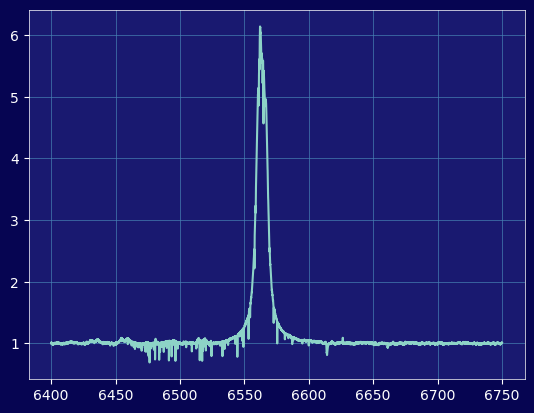

In [4]:
plt.plot(mean_spec[:,0], mean_spec[:,1])

figure out good cropping: 

In [8]:
%matplotlib qt

In [9]:
plt.plot(mean_spec[:,0], mean_spec[:,1], lw=0.5)

plt.xlim(6520, 6610)

# do this to see about where the H-alpha line rises and then falls back to 
# zero (this is to find where we want to do the integration for equivalent width)
# don't think we can just do it as a zero-crossing thing because there are some deeper dips 
# but they don't really represent where things go to zero 

(6520.0, 6610.0)

In [20]:
plt.ioff

<function matplotlib.pyplot.ioff() -> 'AbstractContextManager'>

Now try to calculate EW: 

In [10]:
# 6537.7 = left 
# 6594 = right 
# (writing here while doing interactive above)
import matplotlib.pyplot as plt # reloading to hopefully reset interactive...

h_alpha_left = 6528 # left bound
h_alpha_right = 6611.5 # right bound 

wl = mean_spec[:,0] # wavelength array 
flux = mean_spec[:,1] # flux array
 
line_mask = ( # create mask for the integration windows
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
) 

line_wave = wl[line_mask] # cut wavelength array for integration
line_flux = flux[line_mask] # cut flux array for integration 

EW = np.trapezoid( # actually do the integral
    1.0 - line_flux,
    line_wave
)

print(np.abs(EW))


56.76454857214463


In [26]:
plt.ioff()

56.76454857214463


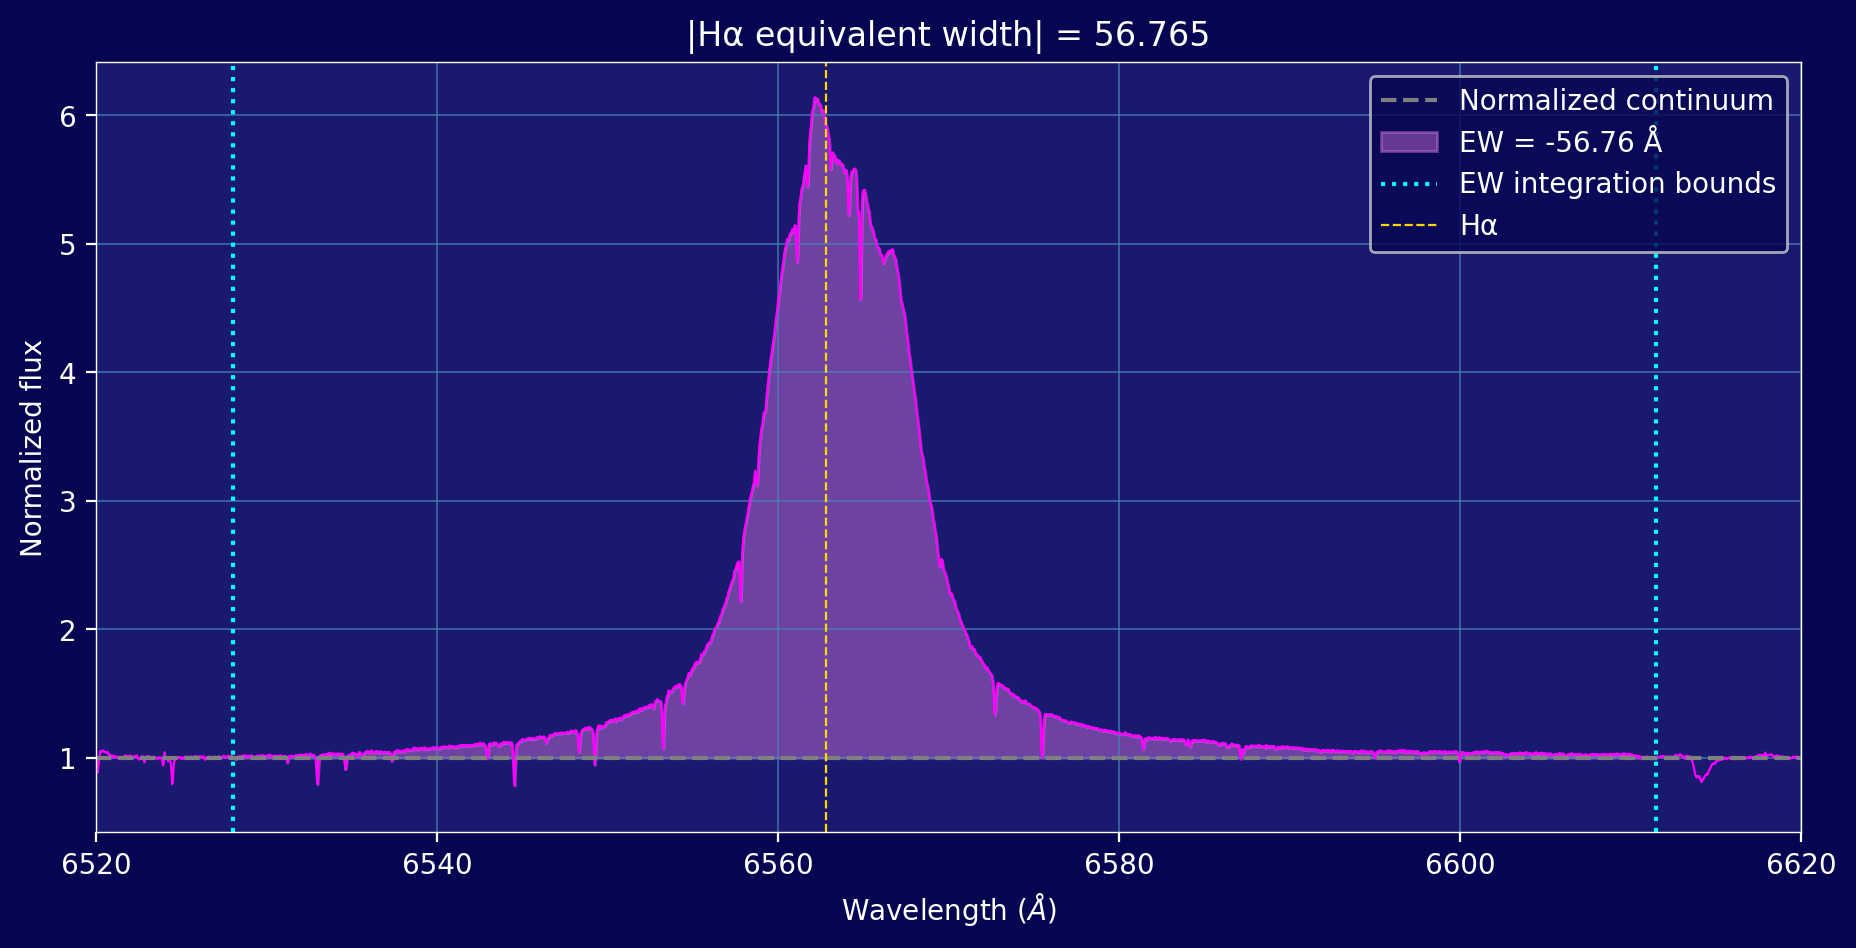

In [12]:
# To plot as well as calculate EW: 

import matplotlib.pyplot as plt # reloading to hopefully reset interactive...

h_alpha_left = 6528 # left bound
h_alpha_right = 6611.5 # right bound 

wl = mean_spec[:,0] # wavelength array 
flux = mean_spec[:,1] # flux array
 
line_mask = ( # create mask for the integration windows
    (wl >= h_alpha_left) &
    (wl <= h_alpha_right)
) 

line_wave = wl[line_mask] # cut wavelength array for integration
line_flux = flux[line_mask] # cut flux array for integration 

EW = np.trapezoid( # actually do the integral
    1.0 - line_flux,
    line_wave
)

print(np.abs(EW))

# plotting: 
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(wl, flux, color="magenta", lw=0.8)

ax.axhline(
    1.0,
    color="gray",
    linestyle="--",
    label="Normalized continuum"
)

ax.fill_between(
    line_wave,
    1.0,
    line_flux,
    color="violet",
    alpha=0.4,
    label=f"EW = {EW:.2f} Å"
)


ax.axvline(h_alpha_left, color="cyan", linestyle=":")
ax.axvline(h_alpha_right, color="cyan", linestyle=":", label = 'EW integration bounds')
ax.axvline(6562.8, ls="--", label="Hα", lw = 0.8, color = 'gold')

ax.set_xlim(6520, 6620)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.set_title(f"|Hα equivalent width| = {np.abs(EW):.3f}")
ax.legend()

fig